"""
# PipelineE K=3 parcelized surface brain maps

This notebook generates **parcelized cortical surface maps** for the selected **PipelineE K=3 fusion HMM** using the **Schaefer-200 / 7-network** atlas already used in preprocessing.

## What this notebook makes
- a **reference Schaefer-7 network surface map**
- **S2 nodal mean connectivity** on the cortical surface
- **S1 − S2** nodal contrast map
- **S3 − S2** nodal contrast map
- optional tables of parcel-wise values

## Why this notebook is separate
These maps are meant to be more manuscript-friendly than the earlier smoothed-looking surfaces. The key design choices here are:
- **one value per parcel** (parcelized, not vertex-wise smoothing)
- **network borders overlaid**
- **consistent views and color scales**
- a **reference map** to help the reader understand the atlas layout

"""
r"""
## What is “nodal mean connectivity” here?

For a given state-specific parcel × parcel correlation matrix $R^{(k)}$, the **nodal mean connectivity** of parcel $i$ is:

\[
\bar r_i^{(k)} = \frac{1}{N-1} \sum_{j \ne i} R^{(k)}_{ij}
\]

So for each parcel, we take the **mean of its correlations with all other parcels**, excluding the diagonal.

### Interpretation
- large positive values mean that the parcel tends to be **more positively correlated with the rest of the brain** in that state
- smaller values mean **weaker average coupling** to the rest of the brain in that state
- contrast maps such as **S1 − S2** or **S3 − S2** show how that parcel’s average coupling changes relative to the dominant/reference state

### Units
The color scale is in **Pearson correlation units** (`r`), which are **dimensionless**.
- absolute maps show **mean r**
- contrast maps show **Δ mean r**

So these are not activation units like BOLD percent signal change; they are **summary connectivity values** derived from the state-specific BOLD correlation matrices.

"""

Imports OK
RESULT_ROOT: /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15
ATLAS_NII  : /mnt/c/EEGFMRI_PIPELINE/templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_res-01_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.nii.gz
ATLAS_TSV  : /mnt/c/EEGFMRI_PIPELINE/templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.tsv
OUT_DIR    : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/brainmap_surfaces
Helper functions OK
state_signature_ut_boldcorr shape: (3, 19900)
n_states: 3
n_parcels: 200
Saved: /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/brainmap_surfaces/tables/parcel_nodal_mean_values.tsv
   atlas_id               label  parcel_index0 network  S1_mean_r  S2_mean_r  \
0         1  7Networks_LH_Vis_1  

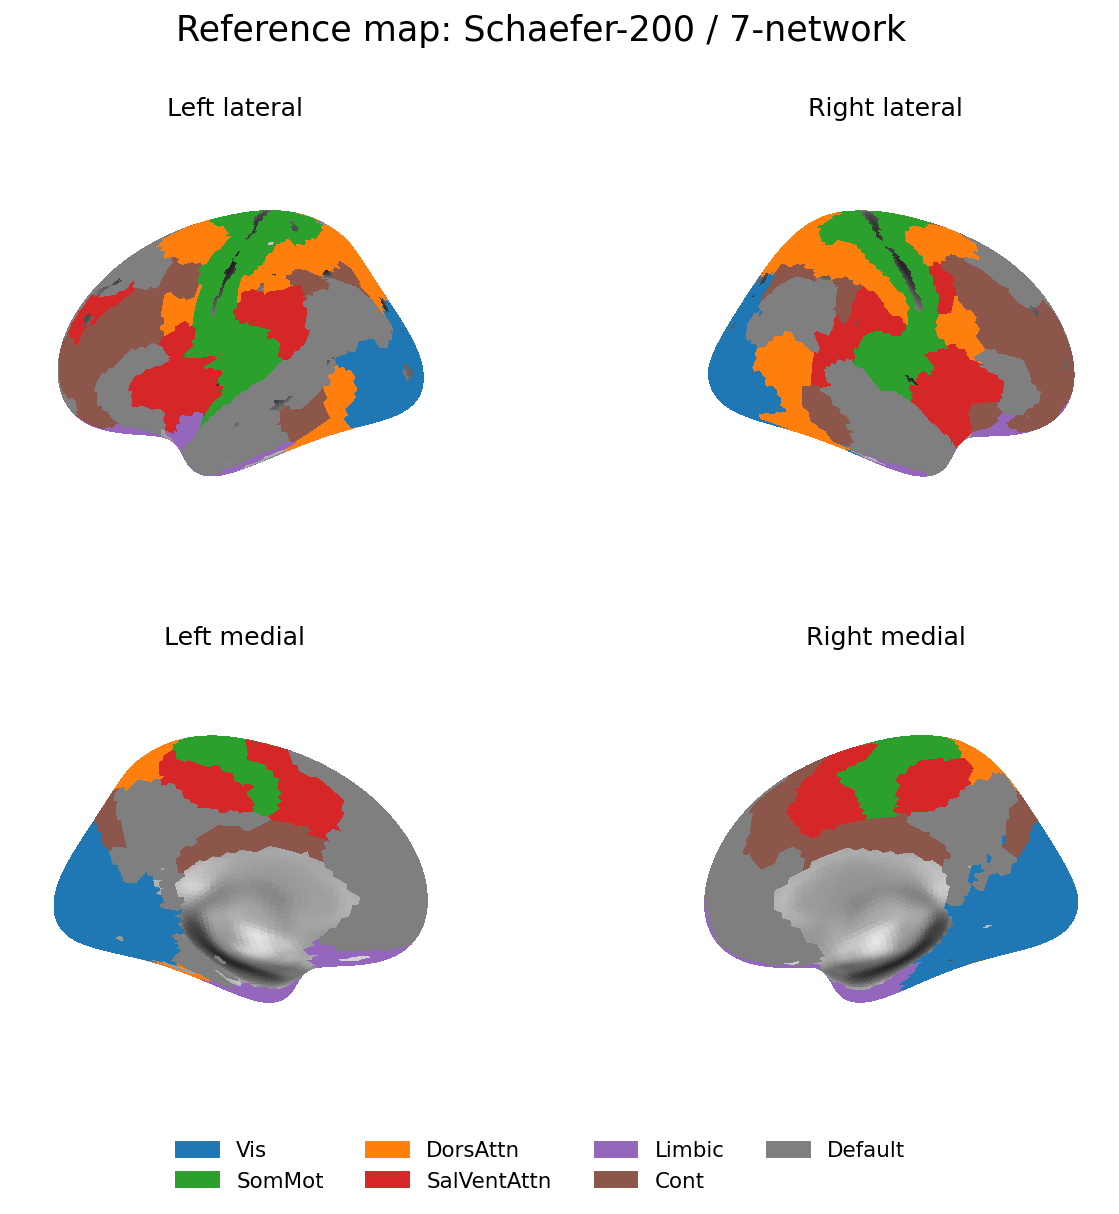

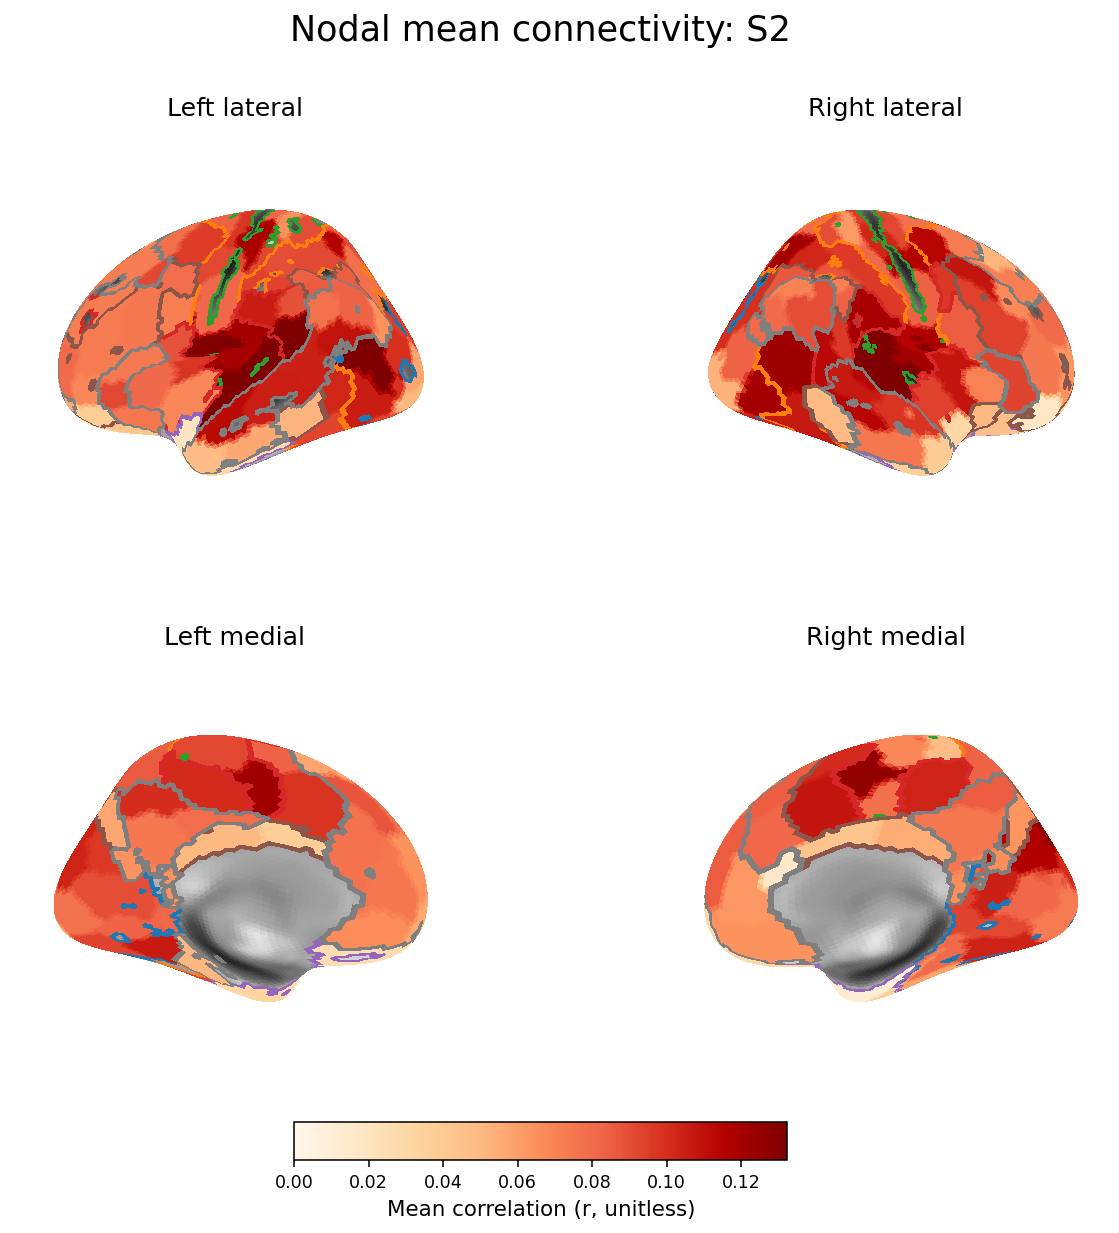

Contrast scale: -0.0884886724082402 0.0884886724082402


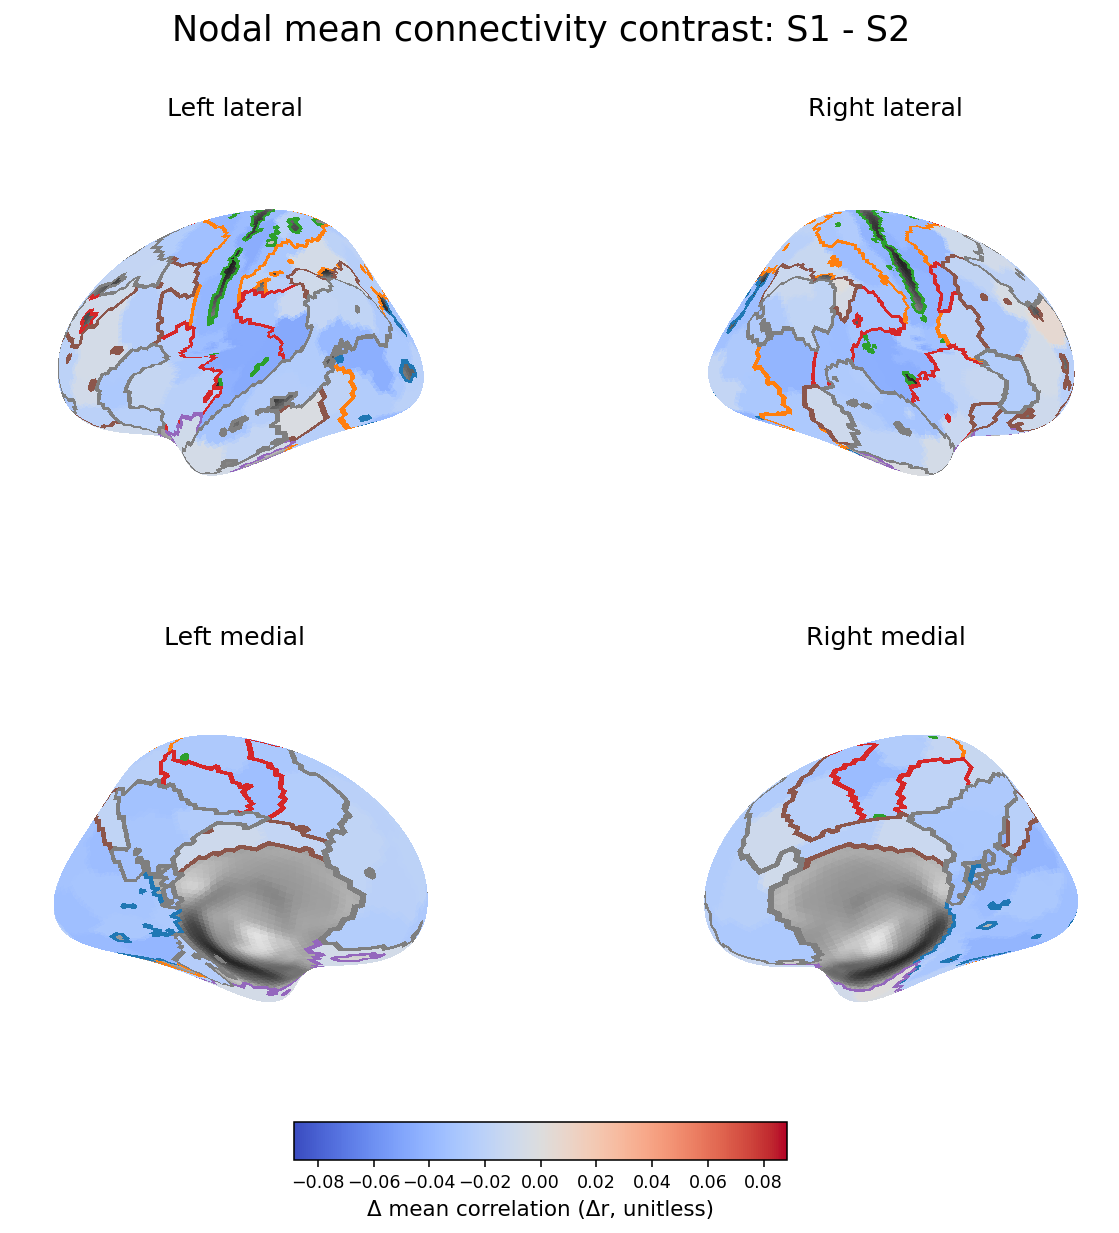

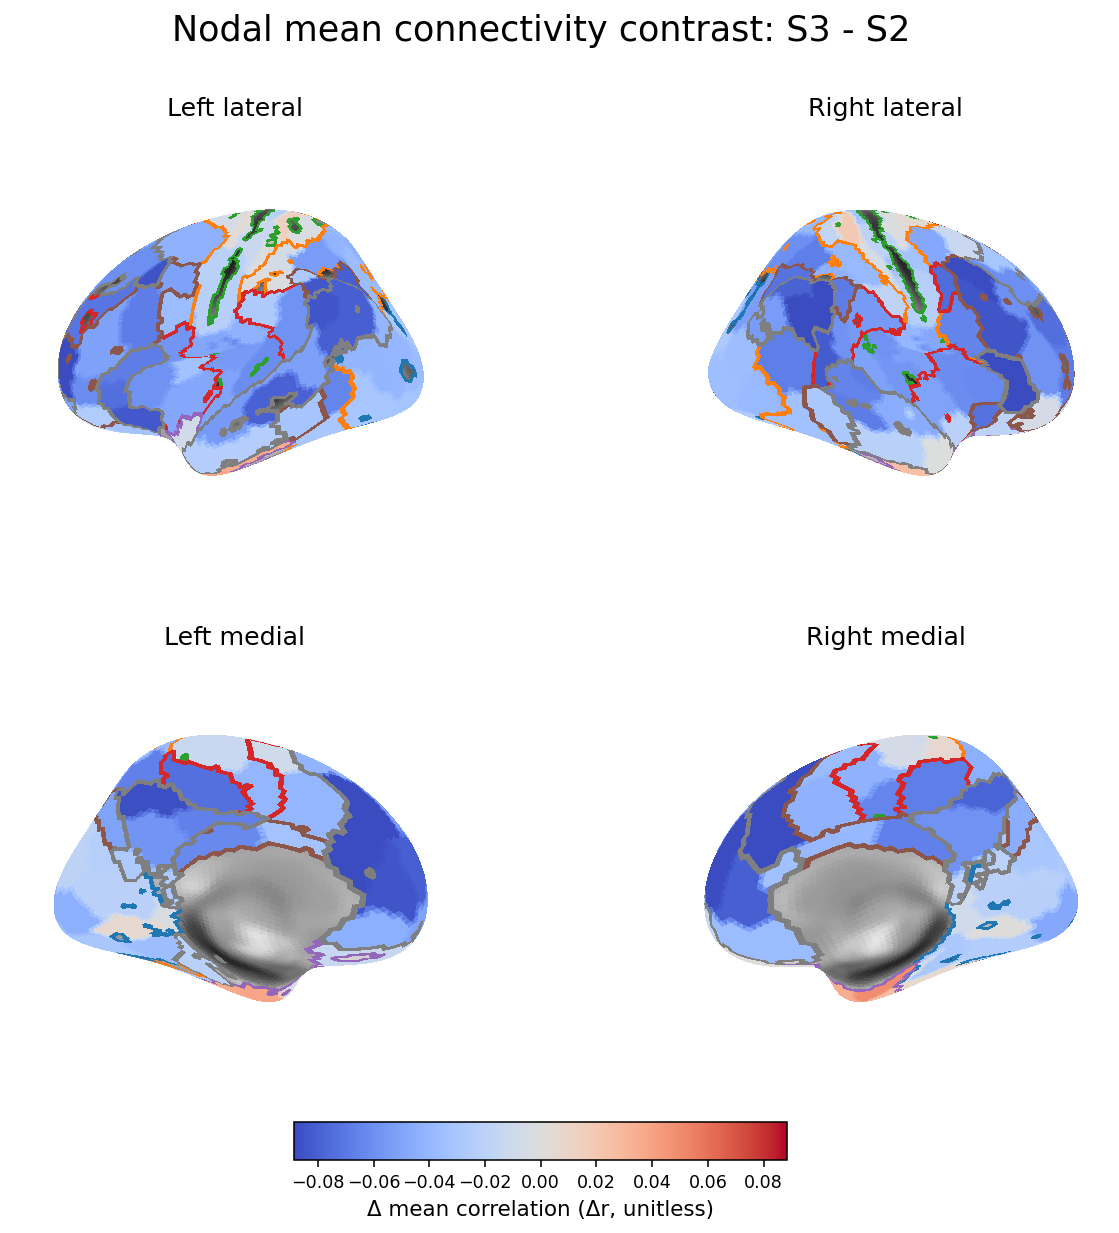

Saved: /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/brainmap_surfaces/tables/top10_parcels_by_state_nodal_mean.tsv
                                 label      network    mean_r state
0                7Networks_LH_SomMot_2       SomMot  0.103268    S1
1         7Networks_RH_DorsAttn_Post_8     DorsAttn  0.099337    S1
2         7Networks_LH_DorsAttn_Post_8     DorsAttn  0.096182    S1
3                7Networks_LH_SomMot_4       SomMot  0.095315    S1
4                  7Networks_RH_Vis_14          Vis  0.092730    S1
5                   7Networks_RH_Vis_5          Vis  0.092004    S1
6             7Networks_RH_Cont_PFCl_7         Cont  0.091374    S1
7    7Networks_RH_SalVentAttn_FrOper_4  SalVentAttn  0.090190    S1
8                7Networks_LH_SomMot_1       SomMot  0.089904    S1
9               7Networks_RH_SomMot_11       SomMot  0.089070    S1
10               7Networks_LH_SomMot_2       SomMot  0.15001

,label,network,delta_mean_r,rank_type
0,7Networks_RH_Cont_PFCl_5,Cont,0.005798,positive
1,7Networks_RH_Cont_Par_2,Cont,0.001113,positive
2,7Networks_RH_Limbic_TempPole_3,Limbic,0.000890,positive
3,7Networks_RH_Limbic_TempPole_2,Limbic,-0.002107,positive
4,7Networks_LH_Cont_Temp_1,Cont,-0.002300,positive
5,7Networks_LH_Limbic_TempPole_3,Limbic,-0.003609,positive
6,7Networks_RH_Cont_PFCl_6,Cont,-0.004200,positive
7,7Networks_RH_Cont_Par_1,Cont,-0.004959,positive
8,7Networks_LH_Cont_PFCl_4,Cont,-0.006319,positive
9,7Networks_LH_Limbic_TempPole_1,Limbic,-0.006564,positive


Saved: /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/brainmap_surfaces/tables/S3_minus_S2_top_parcels.tsv


,label,network,delta_mean_r,rank_type
0,7Networks_RH_Limbic_TempPole_3,Limbic,0.049199,positive
1,7Networks_LH_Limbic_TempPole_1,Limbic,0.039124,positive
2,7Networks_LH_Limbic_TempPole_2,Limbic,0.036192,positive
3,7Networks_RH_Limbic_TempPole_1,Limbic,0.035113,positive
4,7Networks_RH_Limbic_TempPole_2,Limbic,0.025426,positive
5,7Networks_RH_SomMot_15,SomMot,0.019059,positive
6,7Networks_LH_SomMot_13,SomMot,0.014056,positive
7,7Networks_RH_SomMot_17,SomMot,0.007044,positive
8,7Networks_LH_Vis_4,Vis,0.006612,positive
9,7Networks_RH_Vis_1,Vis,0.006591,positive


'\n## Recommended manuscript use\n\nFor the manuscript, I would use these as:\n\n- **Supplementary brain-map figure**\n  - reference Schaefer-7 map\n  - **S2 nodal mean connectivity**\n  - **S1 − S2** contrast\n  - **S3 − S2** contrast\n\nThis keeps the main text focused on:\n- state dynamics\n- network block heatmaps\n- ranked network contrasts\n\nand uses the surface maps as anatomically intuitive support.\n\n'

In [1]:

from pathlib import Path
import json, math, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches as mpatches
from matplotlib.colors import ListedColormap, TwoSlopeNorm

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 300)

try:
    import nibabel as nib
except Exception as e:
    raise ImportError("This notebook needs nibabel.") from e

try:
    from nilearn import plotting, surface, datasets
except Exception as e:
    raise ImportError("This notebook needs nilearn.") from e

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
print("Imports OK")

# =========================
# User config
# =========================
RESULT_ROOT = Path(
    "/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/"
    "PipelineE_final_K03_intermediate_nolags_minlen15"
)
FINAL_DIR = RESULT_ROOT / "final"

# TemplateFlow cache used earlier in preprocessing
TEMPLATEFLOW_HOME = Path("/mnt/c/EEGFMRI_PIPELINE/templateflow")
TF_TPL_DIR = TEMPLATEFLOW_HOME / "tpl-MNI152NLin2009cAsym"
ATLAS_NII = TF_TPL_DIR / "tpl-MNI152NLin2009cAsym_res-01_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.nii.gz"
ATLAS_TSV = TF_TPL_DIR / "tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.tsv"
ATLAS_TXT = TF_TPL_DIR / "tpl-MNI152NLin2009cAsym_res-01_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.txt"

STATE_SIGNATURE_FILE = FINAL_DIR / "state_signature_ut_boldcorr.npy"
STATE_SUMMARY_FILE = RESULT_ROOT / "state_summary_table.tsv"  # optional, for choosing S2 automatically

OUT_DIR = RESULT_ROOT / "brainmap_surfaces"
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
for p in [OUT_DIR, FIG_DIR, TAB_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Visual choices
NETWORK_ORDER = ["Vis", "SomMot", "DorsAttn", "SalVentAttn", "Limbic", "Cont", "Default"]
NETWORK_COLORS = {
    "Vis": "#1f77b4",
    "SomMot": "#2ca02c",
    "DorsAttn": "#ff7f0e",
    "SalVentAttn": "#d62728",
    "Limbic": "#9467bd",
    "Cont": "#8c564b",
    "Default": "#7f7f7f",
}
BORDER_COLOR = "black"
BORDER_LINEWIDTH = 1.0
FSAVERAGE_MESH = "fsaverage5"   # lighter and usually good enough for manuscript figures

# State selection
REFERENCE_STATE = 2  # 1-based; dominant/reference state = S2
CONTRAST_STATES = [1, 3]  # S1-S2 and S3-S2

# Color limits
ABS_VMAX_QUANTILE = 0.98
CONTRAST_VMAX_QUANTILE = 0.98

print("RESULT_ROOT:", RESULT_ROOT)
print("ATLAS_NII  :", ATLAS_NII)
print("ATLAS_TSV  :", ATLAS_TSV)
print("OUT_DIR    :", OUT_DIR)

r"""
## Notes on atlas availability

Based on your earlier setup notes, you already downloaded the **volumetric** Schaefer atlas and TSV label table into `TEMPLATEFLOW_HOME`:

- `tpl-MNI152NLin2009cAsym_res-01_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.nii.gz`
- `tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.tsv`

That is enough for:
- parcel identities
- parcel-to-network labels
- parcel values on the atlas

For **surface rendering**, this notebook uses **fsaverage** surfaces from Nilearn and projects the volumetric atlas labels onto those surfaces. So:
- you likely **already have the core atlas files**
- you may or may not already have the **fsaverage surface files** cached locally
- if not, Nilearn may download them the first time

So the short answer is: **yes, you likely already have the key Schaefer atlas mapping in TemplateFlow for this workflow**, and the notebook builds the surface version from those files.

"""
# =========================
# Helpers
# =========================

def infer_n_from_ut_length(m):
    n = int((1 + math.sqrt(1 + 8 * m)) / 2)
    if n * (n - 1) // 2 != m:
        raise ValueError(f"Upper-triangle length {m} does not match any n x n matrix")
    return n


def ut_to_square(vec, fill_diag=1.0):
    vec = np.asarray(vec)
    n = infer_n_from_ut_length(vec.size)
    M = np.zeros((n, n), dtype=float)
    iu = np.triu_indices(n, 1)
    M[iu] = vec
    M[(iu[1], iu[0])] = vec
    np.fill_diagonal(M, fill_diag)
    return M


def parse_network(label):
    parts = str(label).split("_")
    return parts[2] if len(parts) >= 4 else "Unknown"


def load_schaefer_table(tsv_path):
    df = pd.read_csv(tsv_path, sep="\t")
    lower = {c.lower(): c for c in df.columns}

    # Prefer explicit numeric atlas IDs when available.
    id_col = None
    for cand in ["index", "id"]:
        if cand in lower:
            id_col = lower[cand]
            break

    if id_col is None:
        ids = np.arange(1, len(df) + 1, dtype=int)
    else:
        ids_series = pd.to_numeric(df[id_col], errors="coerce")
        fallback = pd.Series(np.arange(1, len(df) + 1), index=df.index, dtype="int64")
        ids = ids_series.where(ids_series.notna(), fallback).astype(int).to_numpy()

    name_col = None
    for cand in ["name", "label", "labels"]:
        if cand in lower:
            name_col = lower[cand]
            break
    if name_col is None:
        raise ValueError("Could not find a parcel-name column in the Schaefer TSV")

    out = pd.DataFrame({
        "atlas_id": ids,
        "label": df[name_col].astype(str).tolist(),
    })
    out = out.sort_values("atlas_id").reset_index(drop=True)
    out["parcel_index0"] = np.arange(len(out))
    out["network"] = out["label"].map(parse_network)
    return out


def compute_nodal_mean_r(mat):
    tmp = mat.copy().astype(float)
    np.fill_diagonal(tmp, np.nan)
    return np.nanmean(tmp, axis=1)


def project_label_img_to_surface(label_img, mesh, interpolation="nearest"):
    # Try robust nearest-label projection across nilearn versions
    try:
        vals = surface.vol_to_surf(label_img, mesh, interpolation="nearest_most_frequent")
    except Exception:
        try:
            vals = surface.vol_to_surf(label_img, mesh, interpolation="nearest")
        except Exception:
            vals = surface.vol_to_surf(label_img, mesh)
    vals = np.asarray(vals)
    vals = np.rint(vals).astype(int)
    return vals


def map_parcel_values_to_vertices(parcel_ids_vertex, parcel_values, atlas_ids):
    atlas_ids = np.asarray(atlas_ids)
    lut = {int(aid): float(parcel_values[i]) for i, aid in enumerate(atlas_ids)}
    out = np.full(parcel_ids_vertex.shape, np.nan, dtype=float)
    for aid, val in lut.items():
        out[parcel_ids_vertex == aid] = val
    return out


def map_network_ids_to_vertices(parcel_ids_vertex, schaefer_df, network_order):
    network_to_id = {net: i + 1 for i, net in enumerate(network_order)}
    aid_to_netid = {
        int(row.atlas_id): network_to_id.get(row.network, 0)
        for row in schaefer_df.itertuples(index=False)
    }
    out = np.zeros(parcel_ids_vertex.shape, dtype=int)
    for aid, netid in aid_to_netid.items():
        out[parcel_ids_vertex == aid] = netid
    return out


def compute_symmetric_limits(arrays, quantile=0.98):
    vals = np.concatenate([np.ravel(np.asarray(a)) for a in arrays])
    vals = vals[np.isfinite(vals)]
    vmax = np.quantile(np.abs(vals), quantile)
    return float(vmax)


def add_network_legend(fig, network_order, network_colors, loc=(0.5, 0.02), ncol=4):
    handles = [mpatches.Patch(color=network_colors[n], label=n) for n in network_order]
    fig.legend(handles=handles, loc="lower center", ncol=ncol, frameon=False, bbox_to_anchor=loc)


def savefig(fig, name):
    fig.savefig(FIG_DIR / name, bbox_inches="tight")
    plt.show()

print("Helper functions OK")

# =========================
# Load state matrices and compute nodal values
# =========================
if not STATE_SIGNATURE_FILE.exists():
    raise FileNotFoundError(f"Missing state signature file: {STATE_SIGNATURE_FILE}")
if not ATLAS_NII.exists():
    raise FileNotFoundError(f"Missing atlas NIfTI: {ATLAS_NII}")
if not ATLAS_TSV.exists():
    raise FileNotFoundError(f"Missing atlas TSV: {ATLAS_TSV}")

state_ut = np.load(STATE_SIGNATURE_FILE)
K, M = state_ut.shape
n_parc = infer_n_from_ut_length(M)
print("state_signature_ut_boldcorr shape:", state_ut.shape)
print("n_states:", K)
print("n_parcels:", n_parc)

state_mats = [ut_to_square(state_ut[k], fill_diag=1.0) for k in range(K)]
nodal_mean = np.vstack([compute_nodal_mean_r(M) for M in state_mats])  # K x N

schaefer_df = load_schaefer_table(ATLAS_TSV)
if len(schaefer_df) != n_parc:
    raise ValueError(f"Atlas TSV has {len(schaefer_df)} labels but state matrices imply {n_parc} parcels")

ref_idx = REFERENCE_STATE - 1
contrast_indices = [s - 1 for s in CONTRAST_STATES]
contrast_names = [f"S{s} - S{REFERENCE_STATE}" for s in CONTRAST_STATES]

contrast_vals = {f"S{s} - S{REFERENCE_STATE}": nodal_mean[s-1] - nodal_mean[ref_idx] for s in CONTRAST_STATES}

nodal_table = schaefer_df.copy()
for k in range(K):
    nodal_table[f"S{k+1}_mean_r"] = nodal_mean[k]
for s in CONTRAST_STATES:
    nodal_table[f"S{s}_minus_S{REFERENCE_STATE}"] = nodal_mean[s-1] - nodal_mean[ref_idx]

nodal_table.to_csv(TAB_DIR / "parcel_nodal_mean_values.tsv", sep="\t", index=False)
print("Saved:", TAB_DIR / "parcel_nodal_mean_values.tsv")
print(nodal_table.head())

# =========================
# Load atlas and fsaverage surfaces
# =========================
atlas_img = nib.load(str(ATLAS_NII))
fsavg = datasets.fetch_surf_fsaverage(mesh=FSAVERAGE_MESH)

plot_meshes = {
    "left": fsavg.infl_left,
    "right": fsavg.infl_right,
}
project_meshes = {
    "left": fsavg.pial_left,
    "right": fsavg.pial_right,
}
bg_maps = {
    "left": fsavg.sulc_left,
    "right": fsavg.sulc_right,
}

parcel_ids_vertex = {}
network_ids_vertex = {}
for hemi in ["left", "right"]:
    pids = project_label_img_to_surface(atlas_img, project_meshes[hemi])
    # Clean up background / NaN vertices so they do not become huge negative ints.
    pids = np.where(np.isfinite(pids) & (pids > 0), pids, 0).astype(int)
    parcel_ids_vertex[hemi] = pids
    network_ids_vertex[hemi] = map_network_ids_to_vertices(parcel_ids_vertex[hemi], schaefer_df, NETWORK_ORDER)
    print(hemi, "parcel ids min/max:", np.nanmin(parcel_ids_vertex[hemi]), np.nanmax(parcel_ids_vertex[hemi]))

network_cmap = ListedColormap([NETWORK_COLORS[n] for n in NETWORK_ORDER])
print("fsaverage + projected labels ready")

# =========================
# Plotting helpers for 4-view surface figures
# =========================

def _draw_network_boundaries(ax, hemi):
    for net_idx, net in enumerate(NETWORK_ORDER, start=1):
        roi = (network_ids_vertex[hemi] == net_idx).astype(np.uint8)
        if roi.sum() < 10:
            continue
        try:
            plotting.plot_surf_contours(
                plot_meshes[hemi],
                roi_map=roi,
                levels=[1],
                axes=ax,
                colors=[NETWORK_COLORS[net]],
                linewidths=BORDER_LINEWIDTH,
                legend=False,
            )
        except Exception:
            pass


def plot_four_view_reference(network_ids_vertex, title="Reference map: Schaefer-200 / 7-network"):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), subplot_kw={"projection": "3d"})
    view_specs = [
        ("left", "lateral", axes[0, 0]),
        ("right", "lateral", axes[0, 1]),
        ("left", "medial", axes[1, 0]),
        ("right", "medial", axes[1, 1]),
    ]
    for hemi, view, ax in view_specs:
        roi_vals = np.where(network_ids_vertex[hemi] > 0, network_ids_vertex[hemi], np.nan)
        plotting.plot_surf_roi(
            plot_meshes[hemi],
            roi_map=roi_vals,
            hemi=hemi,
            view=view,
            bg_map=bg_maps[hemi],
            colorbar=False,
            cmap=network_cmap,
            axes=ax,
            darkness=None,
        )
        _draw_network_boundaries(ax, hemi)
        ax.set_title(f"{hemi.capitalize()} {view}")
    fig.suptitle(title, y=0.97, fontsize=18)
    add_network_legend(fig, NETWORK_ORDER, NETWORK_COLORS, loc=(0.5, 0.02), ncol=4)
    return fig


def plot_four_view_stat(values_left, values_right, title, vmin=None, vmax=None, cmap="coolwarm", center_zero=False, show_network_legend=False):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), subplot_kw={"projection": "3d"})
    view_specs = [
        ("left", "lateral", axes[0, 0], values_left),
        ("right", "lateral", axes[0, 1], values_right),
        ("left", "medial", axes[1, 0], values_left),
        ("right", "medial", axes[1, 1], values_right),
    ]
    for hemi, view, ax, vals in view_specs:
        vals = np.where(parcel_ids_vertex[hemi] > 0, vals, np.nan)
        plotting.plot_surf_stat_map(
            plot_meshes[hemi],
            stat_map=vals,
            hemi=hemi,
            view=view,
            bg_map=bg_maps[hemi],
            colorbar=False,
            cmap=cmap,
            symmetric_cbar=center_zero,
            vmin=vmin,
            vmax=vmax,
            axes=ax,
            darkness=None,
            threshold=None,
        )
        _draw_network_boundaries(ax, hemi)
        ax.set_title(f"{hemi.capitalize()} {view}")

    # shared colorbar
    if center_zero:
        norm = TwoSlopeNorm(vcenter=0.0, vmin=vmin, vmax=vmax)
        cbar_label = "Δ mean correlation (Δr, unitless)"
    else:
        from matplotlib.colors import Normalize
        norm = Normalize(vmin=vmin, vmax=vmax)
        cbar_label = "Mean correlation (r, unitless)"
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cax = fig.add_axes([0.34, 0.06, 0.32, 0.03])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label(cbar_label)
    fig.suptitle(title, y=0.97, fontsize=18)
    if show_network_legend:
        add_network_legend(fig, NETWORK_ORDER, NETWORK_COLORS, loc=(0.5, 0.015), ncol=4)
    return fig

print("Plotting helpers OK")

# =========================
# Make reference map
# =========================
fig = plot_four_view_reference(network_ids_vertex)
savefig(fig, "Fig_ref_schaefer7_surface.png")

# =========================
# Make S2 nodal mean map
# =========================
ref_vals = nodal_mean[ref_idx]
abs_vmax = compute_symmetric_limits([ref_vals], quantile=ABS_VMAX_QUANTILE)
# mean r is usually mostly positive; keep 0 as the lower bound for readability
abs_vmin = 0.0

vals_left = map_parcel_values_to_vertices(parcel_ids_vertex["left"], ref_vals, schaefer_df["atlas_id"].to_numpy())
vals_right = map_parcel_values_to_vertices(parcel_ids_vertex["right"], ref_vals, schaefer_df["atlas_id"].to_numpy())

fig = plot_four_view_stat(
    vals_left, vals_right,
    title=f"Nodal mean connectivity: S{REFERENCE_STATE}",
    vmin=abs_vmin, vmax=abs_vmax, cmap="OrRd", center_zero=False, show_network_legend=False,
)
savefig(fig, f"Fig_brainmap_nodal_mean_S{REFERENCE_STATE}_parcelized.png")

# =========================
# Make contrast maps: S1-S2 and S3-S2
# =========================
contrast_arrays = [contrast_vals[name] for name in contrast_names]
con_vmax = compute_symmetric_limits(contrast_arrays, quantile=CONTRAST_VMAX_QUANTILE)
con_vmin = -con_vmax
print("Contrast scale:", con_vmin, con_vmax)

for name in contrast_names:
    vals = contrast_vals[name]
    left = map_parcel_values_to_vertices(parcel_ids_vertex["left"], vals, schaefer_df["atlas_id"].to_numpy())
    right = map_parcel_values_to_vertices(parcel_ids_vertex["right"], vals, schaefer_df["atlas_id"].to_numpy())
    safe_name = name.replace(" ", "_").replace("-", "minus")
    fig = plot_four_view_stat(
        left, right,
        title=f"Nodal mean connectivity contrast: {name}",
        vmin=con_vmin, vmax=con_vmax, cmap="coolwarm", center_zero=True, show_network_legend=False,
    )
    savefig(fig, f"Fig_brainmap_{safe_name}_parcelized.png")

# =========================
# Quick table summaries
# =========================
summary_rows = []
for state_idx in range(K):
    vals = nodal_mean[state_idx]
    top_idx = np.argsort(vals)[::-1][:10]
    top = schaefer_df.loc[top_idx, ["label", "network"]].copy()
    top["mean_r"] = vals[top_idx]
    top["state"] = f"S{state_idx+1}"
    summary_rows.append(top)

top_abs = pd.concat(summary_rows, ignore_index=True)
top_abs.to_csv(TAB_DIR / "top10_parcels_by_state_nodal_mean.tsv", sep="\t", index=False)
print("Saved:", TAB_DIR / "top10_parcels_by_state_nodal_mean.tsv")
print(top_abs.head(15))

for name in contrast_names:
    vals = contrast_vals[name]
    top_pos_idx = np.argsort(vals)[::-1][:10]
    top_neg_idx = np.argsort(vals)[:10]
    out = pd.concat([
        schaefer_df.loc[top_pos_idx, ["label", "network"]].assign(delta_mean_r=vals[top_pos_idx], rank_type="positive"),
        schaefer_df.loc[top_neg_idx, ["label", "network"]].assign(delta_mean_r=vals[top_neg_idx], rank_type="negative"),
    ], ignore_index=True)
    safe_name = name.replace(" ", "_").replace("-", "minus")
    out.to_csv(TAB_DIR / f"{safe_name}_top_parcels.tsv", sep="\t", index=False)
    print("Saved:", TAB_DIR / f"{safe_name}_top_parcels.tsv")
    display(out.head(20))

"""
## Recommended manuscript use

For the manuscript, I would use these as:

- **Supplementary brain-map figure**
  - reference Schaefer-7 map
  - **S2 nodal mean connectivity**
  - **S1 − S2** contrast
  - **S3 − S2** contrast

This keeps the main text focused on:
- state dynamics
- network block heatmaps
- ranked network contrasts

and uses the surface maps as anatomically intuitive support.

"""


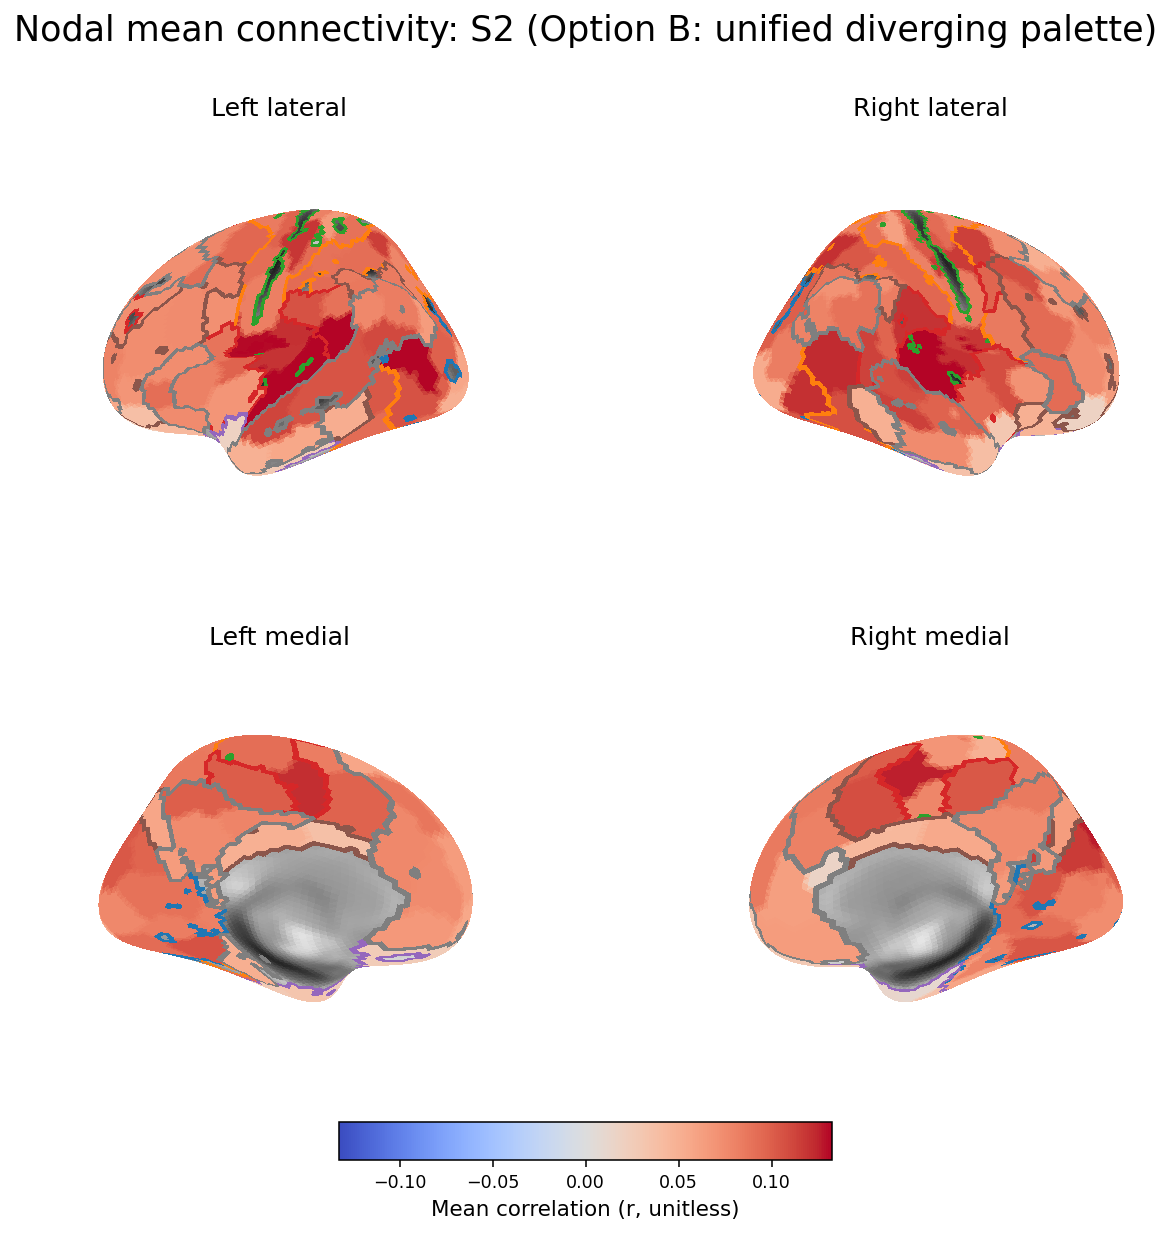

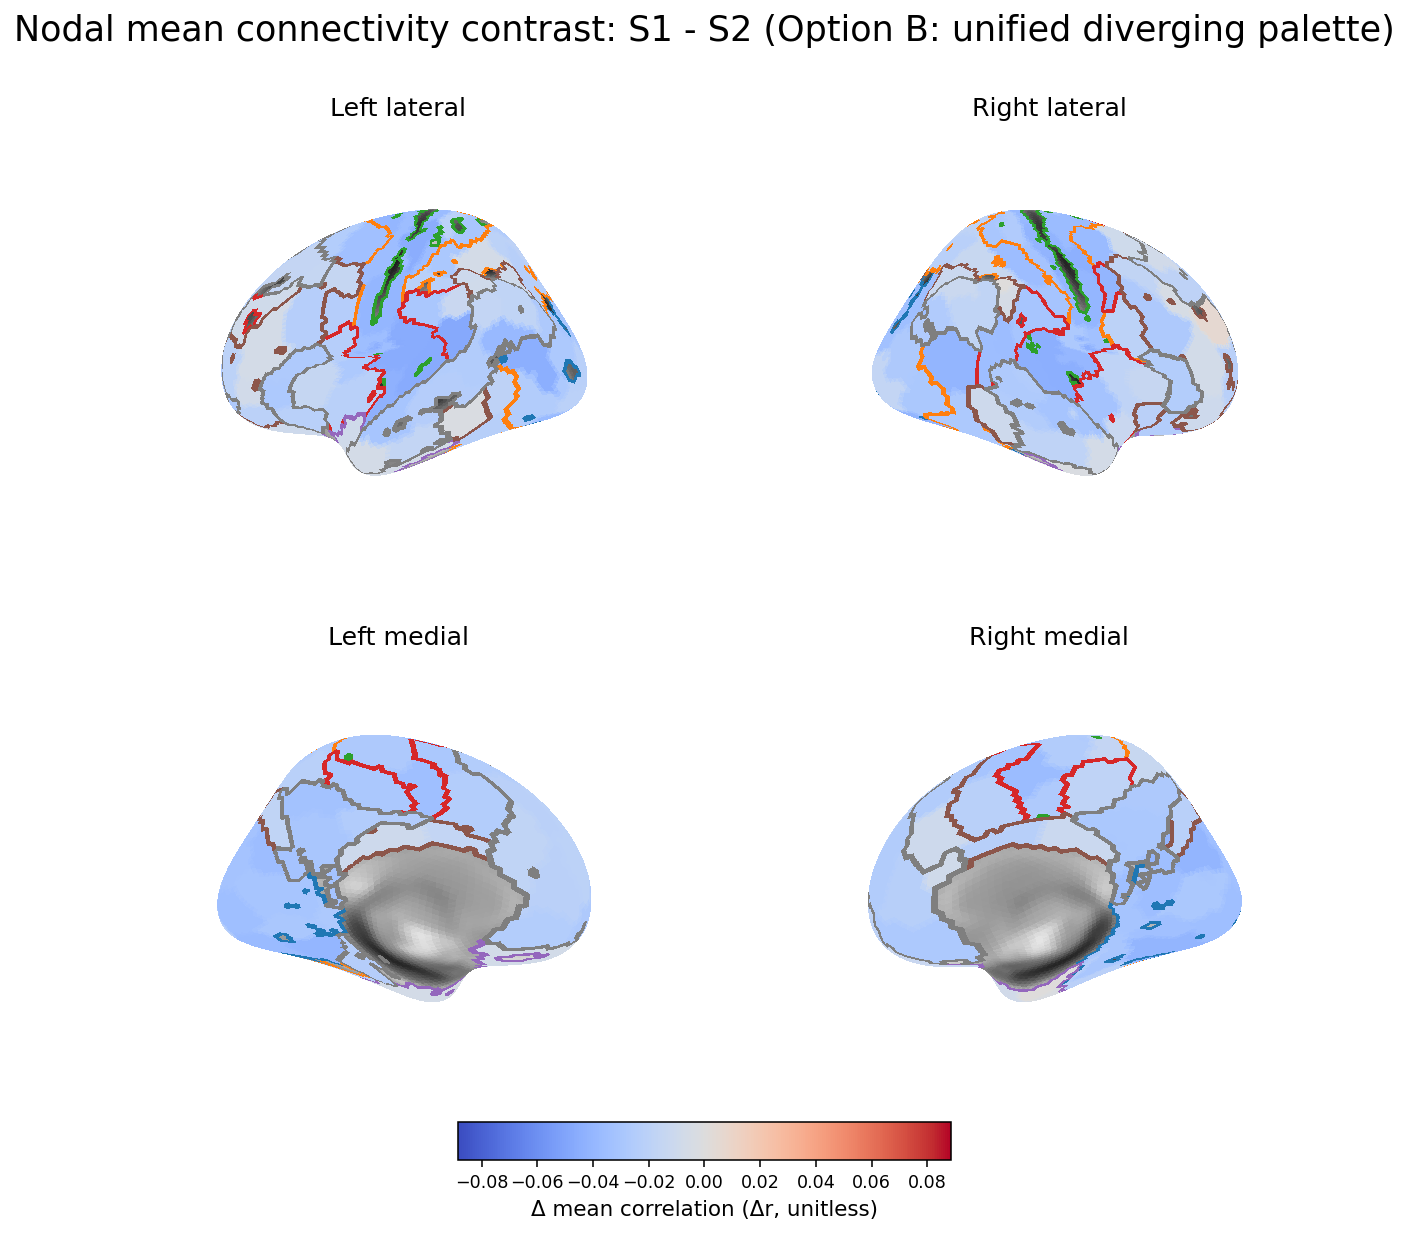

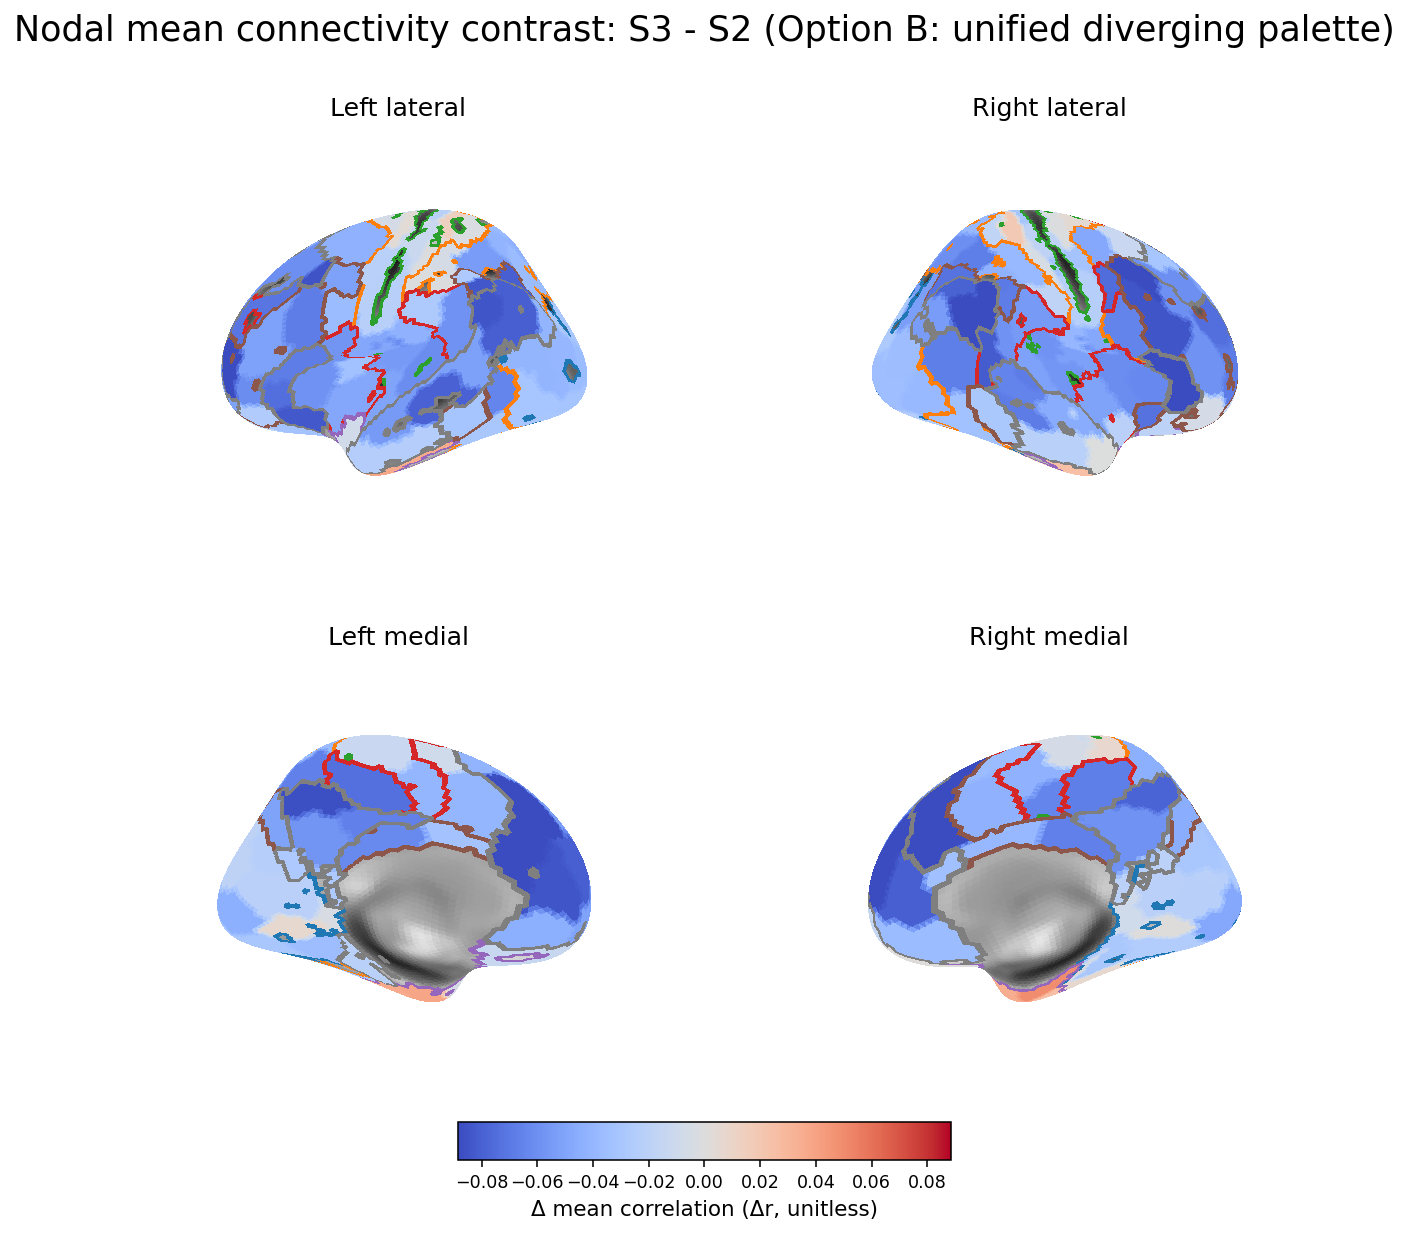

In [4]:
# =========================
# OPTION B (corrected):
# unified diverging palette for all nodal maps,
# but S2 remains an ABSOLUTE map (not a delta map)
# =========================

COMMON_CMAP = "coolwarm"

# ----- Absolute S2 map -----
# Use a zero-centered diverging display range for visual comparability,
# but keep the quantity as ABSOLUTE mean correlation.
abs_div_vmax = compute_symmetric_limits([ref_vals], quantile=ABS_VMAX_QUANTILE)
abs_div_vmin = -abs_div_vmax

fig = plot_four_view_stat(
    vals_left,
    vals_right,
    title=f"Nodal mean connectivity: S{REFERENCE_STATE} (Option B: unified diverging palette)",
    vmin=abs_div_vmin,
    vmax=abs_div_vmax,
    cmap=COMMON_CMAP,
    center_zero=False,          # IMPORTANT: absolute map, not a contrast
    show_network_legend=False,
)
savefig(fig, f"Fig_brainmap_nodal_mean_S{REFERENCE_STATE}_parcelized_optionB.png")


# ----- Contrast maps -----
# Keep a shared symmetric range across S1-S2 and S3-S2
for name in contrast_names:
    vals = contrast_vals[name]

    left = map_parcel_values_to_vertices(
        parcel_ids_vertex["left"],
        vals,
        schaefer_df["atlas_id"].to_numpy()
    )
    right = map_parcel_values_to_vertices(
        parcel_ids_vertex["right"],
        vals,
        schaefer_df["atlas_id"].to_numpy()
    )

    safe_name = name.replace(" ", "_").replace("-", "minus")

    fig = plot_four_view_stat(
        left,
        right,
        title=f"Nodal mean connectivity contrast: {name} (Option B: unified diverging palette)",
        vmin=con_vmin,
        vmax=con_vmax,
        cmap=COMMON_CMAP,
        center_zero=True,        # IMPORTANT: true zero-centered contrast maps
        show_network_legend=False,
    )
    savefig(fig, f"Fig_brainmap_{safe_name}_parcelized_optionB.png")